## Ejercicio 1

### A

In [1]:
import numpy as np
polos = [(0.95,45),(0.95,-45),(0.95,45),(0.95,-45)]
ceros = [(0.80,30), (0.80,-30), (0.80,60), (0.80,-60)]

polos_arr = np.array(polos)
ceros_arr = np.array(ceros)

radio_polo, fase_polo = polos_arr[:, 0], np.deg2rad(polos_arr[:, 1])
radio_cero, fase_cero = ceros_arr[:, 0], np.deg2rad(ceros_arr[:, 1])
#polos_arr[:,0] son todos, del primer elemento, polos_arr[:,1] son todos del segundo

polos_complejos = radio_polo * np.cos(fase_polo) + 1j * radio_polo * np.sin(fase_polo)
ceros_complejos = radio_cero * np.cos(fase_cero) + 1j * radio_cero * np.sin(fase_cero)

polos_complejos = radio_polo * np.cos(fase_polo) + 1j * radio_polo * np.sin(fase_polo)
ceros_complejos = radio_cero * np.cos(fase_cero) + 1j * radio_cero * np.sin(fase_cero)




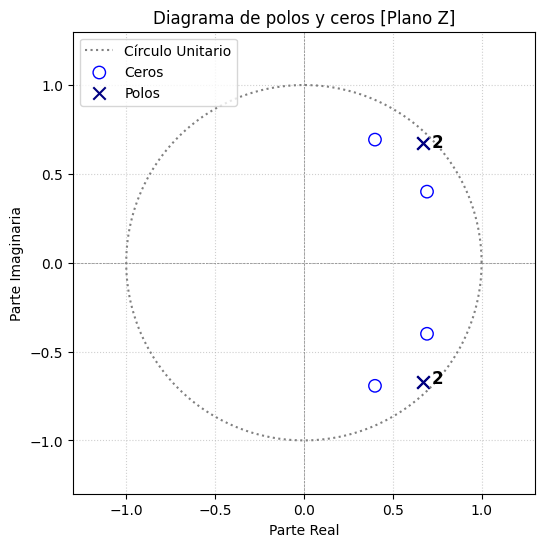

In [2]:
import matplotlib.pyplot as plt

# 1. Configuración de la figura y el plano complejo
fig, ax = plt.subplots(figsize=(6, 6))

# 2. Generación de la circunferencia unitaria (r = 1)
w = np.linspace(0, 2 * np.pi, 500)
circulo_unitario = np.exp(1j * w)
ax.plot(np.real(circulo_unitario), np.imag(circulo_unitario), ':', color='gray', label='Círculo Unitario')

# 3. Graficar líneas de los ejes coordenados (cruces por el origen)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.5)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.5)

# 4. Graficar Ceros ('o') y Polos ('x')
# Nota: polos_complejos y ceros_complejos provienen del paso anterior
ax.scatter(np.real(ceros_complejos), np.imag(ceros_complejos),
           s=80, facecolors='none', edgecolors='blue', marker='o', label='Ceros')
ax.scatter(np.real(polos_complejos), np.imag(polos_complejos),
           s=80, color='navy', marker='x', label='Polos')

# Añadir multiplicidad de los polos si están superpuestos (como indica el "2" en la gráfica)
# Colocamos el texto cerca de las coordenadas de los polos con parte imaginaria positiva y negativa
ax.text(0.72, 0.65, '2', fontsize=12, fontweight='bold')
ax.text(0.72, -0.68, '2', fontsize=12, fontweight='bold')

# 5. Ajustes estéticos y límites del plano
ax.set_title('Diagrama de polos y ceros [Plano Z]')
ax.set_xlabel('Parte Real')
ax.set_ylabel('Parte Imaginaria')
ax.set_xlim([-1.3, 1.3])
ax.set_ylim([-1.3, 1.3])
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal') # Crítico: Evita la distorsión geométrica
ax.legend(loc='upper left')

plt.show()

### B

In [3]:
from scipy import signal

# Asumimos una ganancia inicial unitaria
k = 1.0
b, a = signal.zpk2tf(ceros_complejos, polos_complejos, k)
print(b,a)

[ 1.         -2.18564065  2.38851252 -1.39881001  0.4096    ] [ 1.         -2.68700577  3.61       -2.42502271  0.81450625]


La funcion de transferencia es $$H(z) = \frac{1 - 2.18564065 z^{-1} + 2.38851252 z^{-2} - 1.39881001 z^{-3} + 0.4096 z^{-4}}{1 - 2.68700577 z^{-1} + 3.61 z^{-2} - 2.42502271 z^{-3} + 0.81450625 z^{-4}}$$

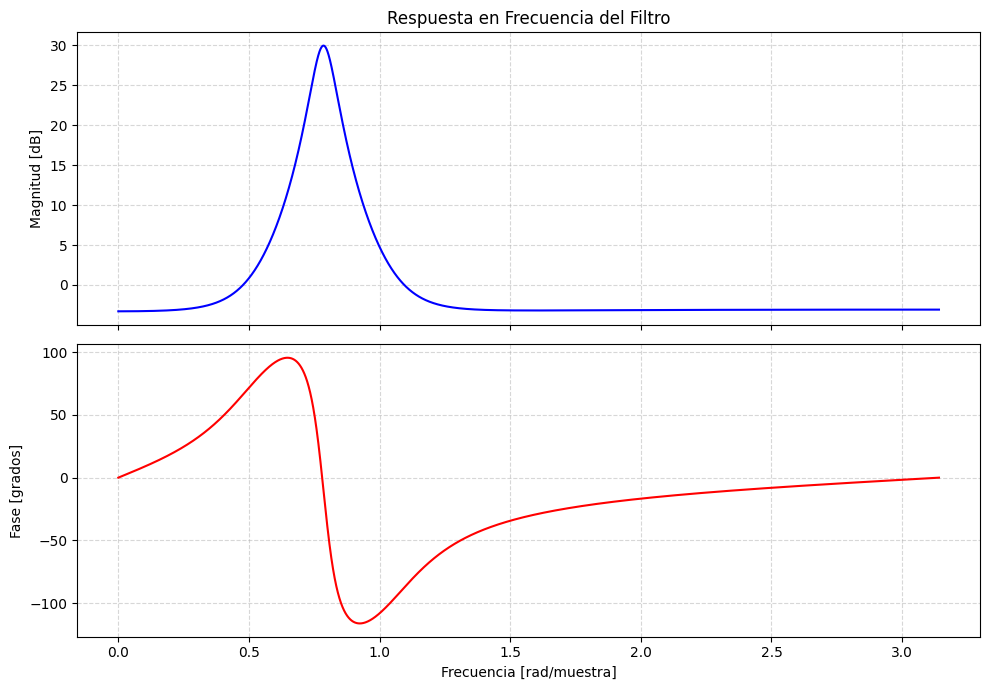

In [4]:
w, h = signal.freqz(b, a, worN=8000) #calcula rta en frecuencia, worN me da la resolucion
#w es el de frecuencias angulares, h es la rta del filtro (compleja)

# magnitud
magnitud_db = 20 * np.log10(np.abs(h)) #el abs de h nos da la magnitud (gain)
# 20*np.log10(...) te deja en decibeles
fase_grados = np.unwrap(np.angle(h)) * 180 / np.pi #np.angle usa arctan
#si nos pasamos de 180, va a devolver el negativo, ej: 182 -> -178
#unwrap corrige esto: nos deja el 182!

# radianes/muestra
eje_x = w
etiqueta_x = 'Frecuencia [rad/muestra]'

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Subplot 1: Magnitud
ax1.plot(eje_x, magnitud_db, color='blue', linewidth=1.5)
ax1.set_title('Respuesta en Frecuencia del Filtro')
ax1.set_ylabel('Magnitud [dB]')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# Subplot 2: Fase
ax2.plot(eje_x, fase_grados, color='red', linewidth=1.5)
ax2.set_ylabel('Fase [grados]')
ax2.set_xlabel(etiqueta_x)
ax2.grid(True, which='both', linestyle='--', alpha=0.5)

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

### C

Para normalizar,

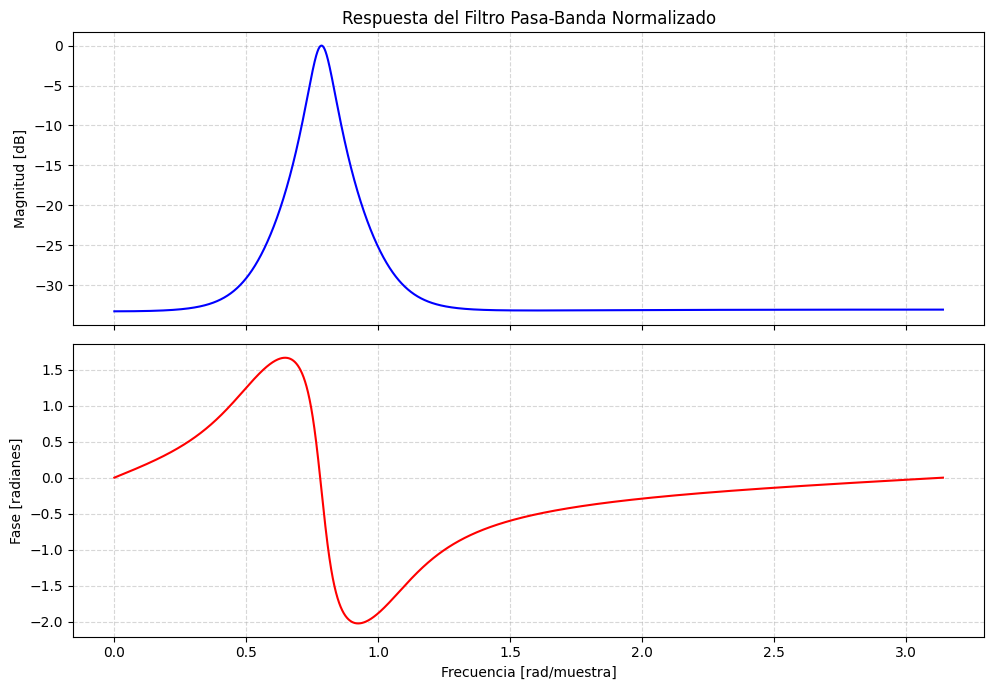

In [5]:
max_ganancia = np.max(np.abs(h))

# normalizo los coeficientes (que la frecuencia que dejo pasar quede max en 1)
b_norm = b / max_ganancia

# respuesta en frecuencia del filtro ya normalizado
w, h = signal.freqz(b_norm, a, worN=8000)
magnitud_db = 20 * np.log10(np.abs(h))
fase_radianes = np.unwrap(np.angle(h))

# 5. Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(w, magnitud_db, color='blue', linewidth=1.5)
ax1.set_title('Respuesta del Filtro Pasa-Banda Normalizado')
ax1.set_ylabel('Magnitud [dB]')
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

ax2.plot(w, fase_radianes, color='red', linewidth=1.5)
ax2.set_ylabel('Fase [radianes]')
ax2.set_xlabel('Frecuencia [rad/muestra]')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Bien! 0dB en la banda de paso, y -30db pasando el rad/muestra

### D

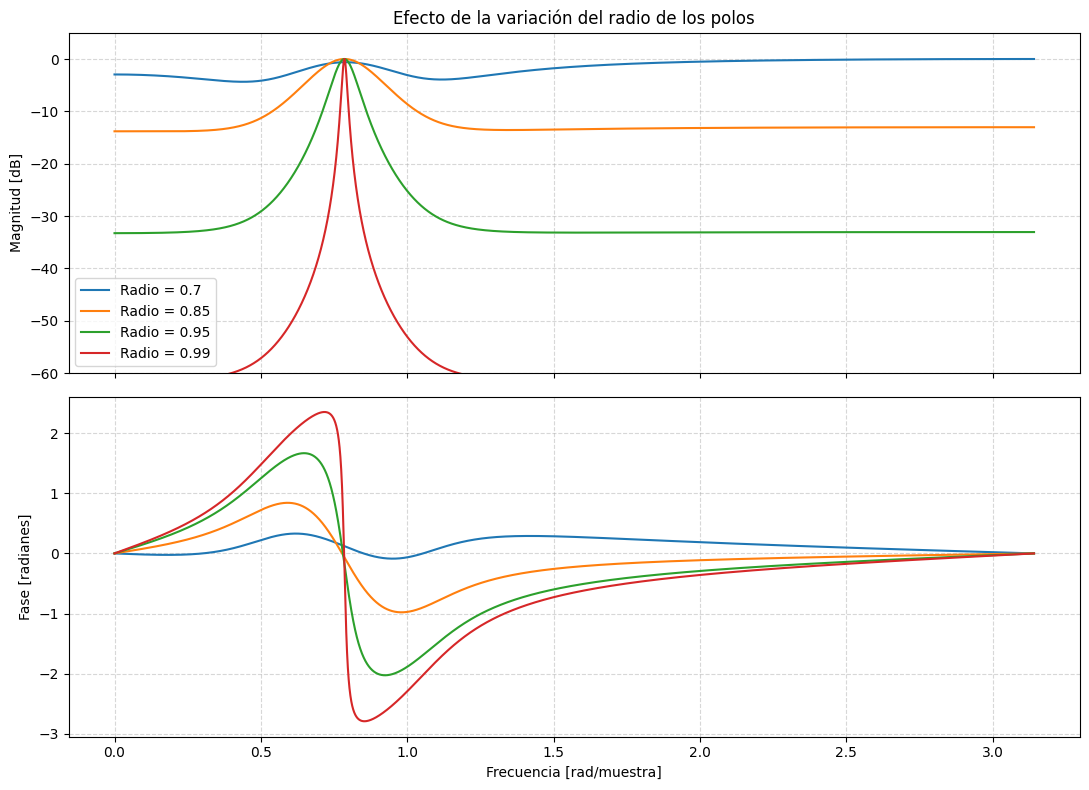

In [6]:

# 1. Definición de ángulos fijos (se mantienen constantes)
fase_polo = np.deg2rad(45)
fase_cero1, fase_cero2 = np.deg2rad(30), np.deg2rad(60)
r_z = 0.80

# Ceros fijos del enunciado
zeros = [r_z*np.exp(1j*fase_cero1), r_z*np.exp(-1j*fase_cero1), r_z*np.exp(1j*fase_cero2), r_z*np.exp(-1j*fase_cero2)]

# Radios de los polos que vamos a comparar
radios_a_probar = [0.70, 0.85, 0.95, 0.99]

# Configuración del gráfico
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

for r_p in radios_a_probar:
    # Reconstruir polos con el radio actual del bucle
    polos = [r_p*np.exp(1j*fase_polo), r_p*np.exp(-1j*fase_polo), r_p*np.exp(1j*fase_polo), r_p*np.exp(-1j*fase_polo)]

    # Obtener función de transferencia
    b, a = signal.zpk2tf(zeros, polos, k=1)

    # Normalizar para que el máximo de cada filtro sea 1 (0 dB)
    _, h_inicial = signal.freqz(b, a, worN=8000)
    b_norm = b / np.max(np.abs(h_inicial))

    # Calcular respuesta en frecuencia final
    w, h = signal.freqz(b_norm, a, worN=8000)
    magnitud_db = 20 * np.log10(np.abs(h))
    fase_radianes = np.unwrap(np.angle(h))

    # Graficar curvas superpuestas
    ax1.plot(w, magnitud_db, label=f'Radio = {r_p}', linewidth=1.5)
    ax2.plot(w, fase_radianes, linewidth=1.5)

# Detalles de formato del panel de Magnitud
ax1.set_title('Efecto de la variación del radio de los polos')
ax1.set_ylabel('Magnitud [dB]')
ax1.set_ylim([-60, 5]) # Acotamos para ver bien el detalle
ax1.grid(True, which='both', linestyle='--', alpha=0.5)
ax1.legend(loc='best')

# Detalles de formato del panel de Fase
ax2.set_ylabel('Fase [radianes]')
ax2.set_xlabel('Frecuencia [rad/muestra]')
ax2.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### E

La relacion $\omega = \frac{2\pi f}{f_s}$ nos va a dictaminar la diferencia en los comportamientos:

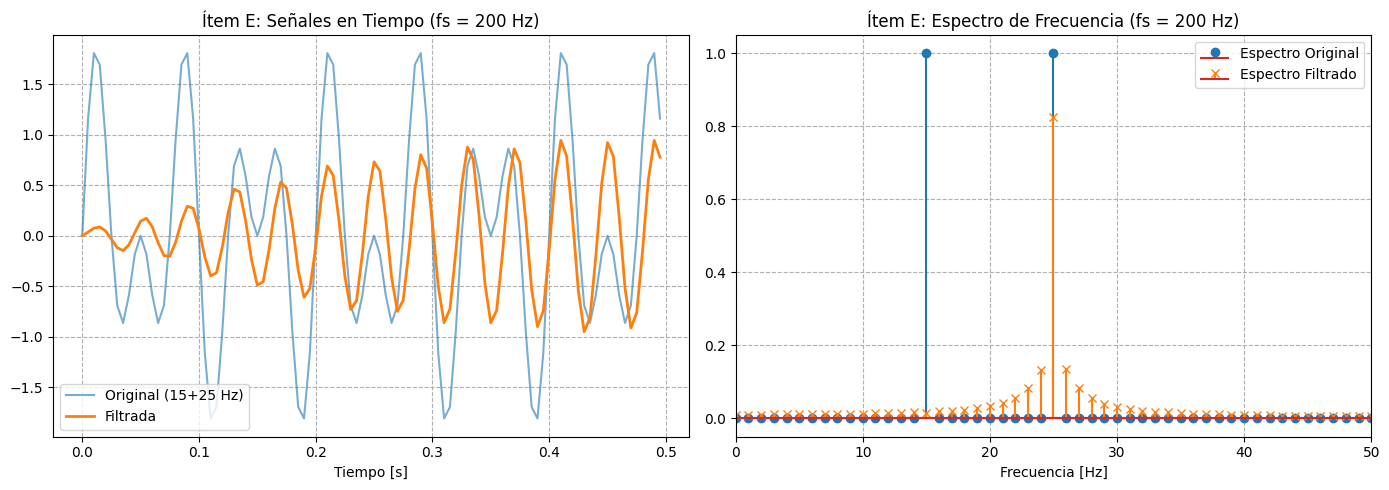

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal


polos = [(0.95, 45), (0.95, -45), (0.95, 45), (0.95, -45)]
ceros = [(0.80, 30), (0.80, -30), (0.80, 60), (0.80, -60)]

polos_arr = np.array(polos)
ceros_arr = np.array(ceros)

radio_polo, fase_polo = polos_arr[:, 0], np.deg2rad(polos_arr[:, 1])
radio_cero, fase_cero = ceros_arr[:, 0], np.deg2rad(ceros_arr[:, 1])

polos_complejos = radio_polo * np.cos(fase_polo) + 1j * radio_polo * np.sin(fase_polo)
ceros_complejos = radio_cero * np.cos(fase_cero) + 1j * radio_cero * np.sin(fase_cero)

# Obtener polinomios y normalizar ganancia máxima a 1 (0 dB)
b, a = signal.zpk2tf(ceros_complejos, polos_complejos, k=1)
_, h_inicial = signal.freqz(b, a, worN=8000)
b_norm = b / np.max(np.abs(h_inicial))

# Componentes de la señal analógica de prueba
f1, f2 = 15, 25

fs_e = 200
duracion_e = 1.0  # 1 segundo de registro
t_e = np.arange(0, duracion_e, 1/fs_e)

# Señal compuesta en el tiempo
x_e = np.sin(2 * np.pi * f1 * t_e) + np.sin(2 * np.pi * f2 * t_e)

# Filtrado digital
y_e = signal.lfilter(b_norm, a, x_e)

# Análisis espectral mediante FFT
N_e = len(t_e)
freqs_e = np.fft.fftfreq(N_e, 1/fs_e)[:N_e//2]
X_e_mag = np.abs(np.fft.fft(x_e))[:N_e//2] * 2 / N_e
Y_e_mag = np.abs(np.fft.fft(y_e))[:N_e//2] * 2 / N_e

# =====================================================================
# VISUALIZACIÓN DE RESULTADOS
# =====================================================================
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Subplot E.1: Tiempo (fs = 200 Hz)
axs[0].plot(t_e[:100], x_e[:100], label='Original (15+25 Hz)', alpha=0.6)
axs[0].plot(t_e[:100], y_e[:100], label='Filtrada', linewidth=2)
axs[0].set_title('Ítem E: Señales en Tiempo (fs = 200 Hz)')
axs[0].set_xlabel('Tiempo [s]')
axs[0].grid(True, linestyle='--')
axs[0].legend()

# Subplot E.2: Espectro (fs = 200 Hz)
axs[1].stem(freqs_e, X_e_mag, linefmt='C0-', markerfmt='C0o', label='Espectro Original')
axs[1].stem(freqs_e, Y_e_mag, linefmt='C1-', markerfmt='C1x', label='Espectro Filtrado')
axs[1].set_title('Ítem E: Espectro de Frecuencia (fs = 200 Hz)')
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_xlim([0,50])
axs[1].grid(True, linestyle='--')
axs[1].legend()

plt.tight_layout()
plt.show()

la relacion $\omega = \frac{2\pi f}{f_s}$ nos va a dictaminar la diferencia en los comportamientos:
para $f_s = 200Hz$ la $f = 15Hz$ nos devuelve $w=27°$, como hay un cero en 30°, se atenua mucho
por otro lado, para $f=25$,nos devuelve $w=45°$ coincidiendo con un polo, por lo que pasa limpia

### F

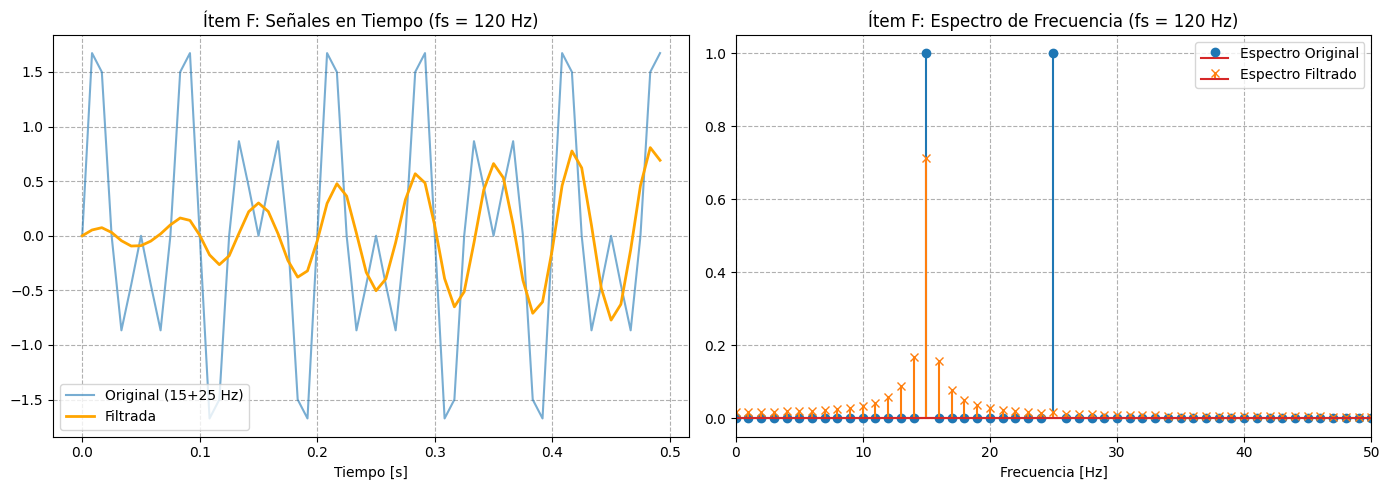

In [8]:
fs_f = 120
duracion_f = 1.0
t_f = np.arange(0, duracion_f, 1/fs_f)

# Señal compuesta a la nueva velocidad de muestreo
x_f = np.sin(2 * np.pi * f1 * t_f) + np.sin(2 * np.pi * f2 * t_f)

# Filtrado con el MISMO diseño polinomial
y_f = signal.lfilter(b_norm, a, x_f)

# Análisis espectral mediante FFT
N_f = len(t_f)
freqs_f = np.fft.fftfreq(N_f, 1/fs_f)[:N_f//2]
X_f_mag = np.abs(np.fft.fft(x_f))[:N_f//2] * 2 / N_f
Y_f_mag = np.abs(np.fft.fft(y_f))[:N_f//2] * 2 / N_f


fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# Subplot F.1: Tiempo (fs = 120 Hz)
axs[0].plot(t_f[:60], x_f[:60], label='Original (15+25 Hz)', alpha=0.6)
axs[0].plot(t_f[:60], y_f[:60], label='Filtrada', linewidth=2, color='orange')
axs[0].set_title('Ítem F: Señales en Tiempo (fs = 120 Hz)')
axs[0].set_xlabel('Tiempo [s]')
axs[0].grid(True, linestyle='--')
axs[0].legend()

# Subplot F.2: Espectro (fs = 120 Hz)
axs[1].stem(freqs_f, X_f_mag, linefmt='C0-', markerfmt='C0o', label='Espectro Original')
axs[1].stem(freqs_f, Y_f_mag, linefmt='C1-', markerfmt='C1x', label='Espectro Filtrado')
axs[1].set_title('Ítem F: Espectro de Frecuencia (fs = 120 Hz)')
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_xlim([0, 50])
axs[1].grid(True, linestyle='--')
axs[1].legend()
plt.tight_layout()
plt.show()


Analogamente, para $f_s = 120Hz$, la $f = 25Hz$ nos devuelve $w=75°$, por lo que un poco se mueve (un poco...)
por otro lado, para $f=15$,nos devuelve $w=45°$ coincidiendo con un polo, por lo que pasa limpia, dominando el sistema

## Ej 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import ipywidgets as widgets
from IPython.display import display # Importación requerida para forzar salida visual
from ipywidgets import interactive  # Importación de contenedor interactivo

# Constantes del sistema
fc = 500
fs = 2000
omega_c = (2 * np.pi * fc) / fs
Omega_c = 2 * fs * np.tan(omega_c / 2) 
#el famoso prewarping: al hacer la bilineal, 
#se comprimen las frecuencias cerca de la freq de nyquist: esto deforma para caer en el 500

def actualizar_grafico(N):
    plt.figure(figsize=(10, 6))
    
    b_lp, a_lp = signal.butter(N, Wn=1.0, btype='low', analog=True)
    b_hp_analog, a_hp_analog = signal.lp2hp(b_lp, a_lp, Omega_c)
    b_digital, a_digital = signal.bilinear(b_hp_analog, a_hp_analog, fs=fs)
    
    w, h = signal.freqz(b_digital, a_digital, worN=8000)
    frecuencias_hz = w * fs / (2 * np.pi)
    magnitud_db = 20 * np.log10(np.abs(h))
    
    magnitud_db[np.isinf(magnitud_db)] = -60

    plt.plot(frecuencias_hz, magnitud_db, label=f'Orden N = {N}', linewidth=2)
    plt.axvline(fc, color='red', linestyle=':', alpha=0.8, label=f'Corte ({fc} Hz)')
    plt.axhline(-3, color='gray', linestyle='--', alpha=0.5, label='Límite -3 dB')
    
    plt.title('Diagrama de Bode Interactivo: Filtro Pasa-Altos')
    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('Magnitud [dB]')
    plt.ylim([-60, 5])
    plt.xlim([0, fs/2])
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.legend(loc='lower right')
    plt.show()

# Contenedor explícito de interfaz y orden de visualización
deslizador = widgets.IntSlider(min=1, max=10, step=1, value=1, description='Orden N:')
interfaz = interactive(actualizar_grafico, N=deslizador)
display(interfaz)

interactive(children=(IntSlider(value=1, description='Orden N:', max=10, min=1), Output()), _dom_classes=('wid…

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24376\3074589010.py:55: RuntimeWarning: divide by zero encountered in log10
  plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb1)), label=f'Chebyshev I (N={N_cheb1})')
C:\Users\Usuario\AppData\Local\Temp\ipykernel_24376\3074589010.py:72: RuntimeWarning: divide by zero encountered in log10
  plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb1_f)), label=f'Chebyshev I (N={menor_orden})')


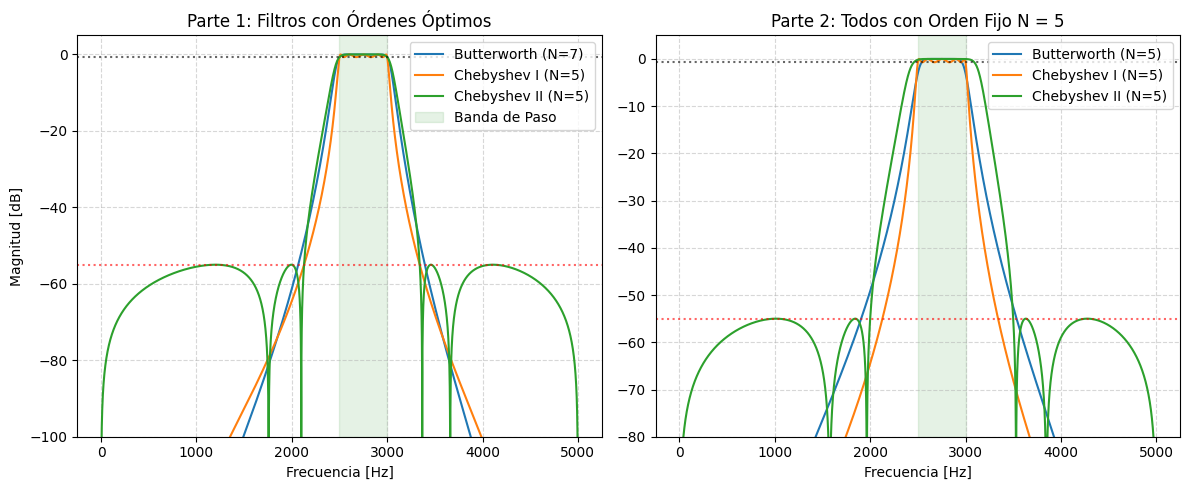

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 10000          # muestreo a 10 kHz
nyq = fs / 2        # Frecuencia de Nyquist: 5 kHz

fp1, fp2 = 2500, 3000   # Banda de paso
# bandas de transición de 500 Hz como máximo
fs1, fs2 = fp1 - 500, fp2 + 500  # 2000 Hz y 3500 Hz (stopband)

# frecuencias normalizadas respecto a Nyquist (rango 0 a 1)
wp = [fp1 / nyq, fp2 / nyq]
ws = [fs1 / nyq, fs2 / nyq]

# Tolerancias del enunciado
gpass = 0.7   # Atenuación máxima permitida en la banda de paso (dB)
gstop = 55.0  # Atenuación mínima requerida en la banda de rechazo (dB)

#  Diseño con optimos

# órdenes optimizados y frecuencias naturales de corte (Wn)
N_butt, Wn_butt = signal.buttord(wp, ws, gpass, gstop)
N_cheb1, Wn_cheb1 = signal.cheb1ord(wp, ws, gpass, gstop)
N_cheb2, Wn_cheb2 = signal.cheb2ord(wp, ws, gpass, gstop)

# Diseñar las funciones de transferencia digitales (b, a)
b_butt, a_butt = signal.butter(N_butt, Wn_butt, btype='bandpass')
b_cheb1, a_cheb1 = signal.cheby1(N_cheb1, gpass, Wn_cheb1, btype='bandpass')
b_cheb2, a_cheb2 = signal.cheby2(N_cheb2, gstop, Wn_cheb2, btype='bandpass')

# Diseño con el menor de los optimos
menor_orden = min(N_butt, N_cheb1, N_cheb2)

# diseño los tres filtros usando ese orden fijo
b_butt_fijo, a_butt_fijo = signal.butter(menor_orden, wp, btype='bandpass')
b_cheb1_fijo, a_cheb1_fijo = signal.cheby1(menor_orden, gpass, wp, btype='bandpass')
b_cheb2_fijo, a_cheb2_fijo = signal.cheby2(menor_orden, gstop, ws, btype='bandpass')

# yyy las respuestas en frecuencia...
w, h_butt = signal.freqz(b_butt, a_butt, worN=8000)
_, h_cheb1 = signal.freqz(b_cheb1, a_cheb1, worN=8000)
_, h_cheb2 = signal.freqz(b_cheb2, a_cheb2, worN=8000)

_, h_butt_f = signal.freqz(b_butt_fijo, a_butt_fijo, worN=8000)
_, h_cheb1_f = signal.freqz(b_cheb1_fijo, a_cheb1_fijo, worN=8000)
_, h_cheb2_f = signal.freqz(b_cheb2_fijo, a_cheb2_fijo, worN=8000)

frecuencias_hz = w * fs / (2 * np.pi)

# --- Gráfico 1: Órdenes Óptimos ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_butt)), label=f'Butterworth (N={N_butt})')
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb1)), label=f'Chebyshev I (N={N_cheb1})')
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb2)), label=f'Chebyshev II (N={N_cheb2})')

# Dibujar líneas guía de la plantilla para verificar cumplimiento
plt.axvspan(fp1, fp2, color='green', alpha=0.1, label='Banda de Paso')
plt.axhline(-gpass, color='black', linestyle=':', alpha=0.6)
plt.axhline(-gstop, color='red', linestyle=':', alpha=0.6)
plt.title('Parte 1: Filtros con Órdenes Óptimos')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.ylim([-100, 5])
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right') 

# Orden Menor Fijo ---
plt.subplot(1, 2, 2)
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_butt_f)), label=f'Butterworth (N={menor_orden})')
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb1_f)), label=f'Chebyshev I (N={menor_orden})')
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb2_f)), label=f'Chebyshev II (N={menor_orden})')

plt.axvspan(fp1, fp2, color='green', alpha=0.1)
plt.axhline(-gpass, color='black', linestyle=':', alpha=0.6)
plt.axhline(-gstop, color='red', linestyle=':', alpha=0.6)
plt.title(f'Parte 2: Todos con Orden Fijo N = {menor_orden}')
plt.xlabel('Frecuencia [Hz]')
plt.ylim([-80, 5])
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')  

plt.tight_layout()
plt.show()

zoomsito a la banda de paso...

C:\Users\Usuario\AppData\Local\Temp\ipykernel_24376\2735918222.py:4: RuntimeWarning: divide by zero encountered in log10
  plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb1)), label=f'Chebyshev I (N={N_cheb1})')


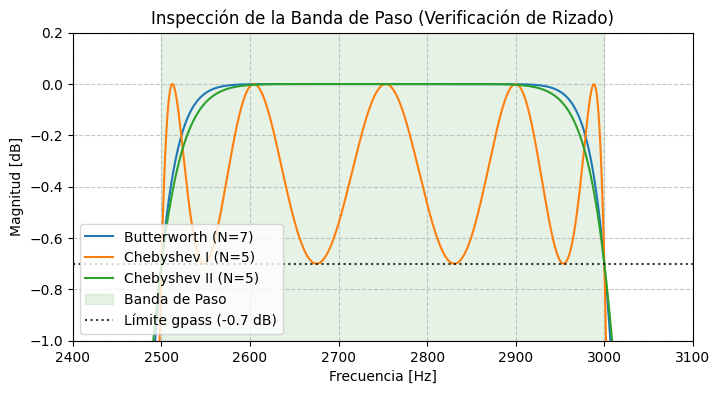

In [16]:
# --- Gráfico de Inspección: Zoom en la Banda de Paso ---
plt.figure(figsize=(8, 4))
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_butt)), label=f'Butterworth (N={N_butt})')
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb1)), label=f'Chebyshev I (N={N_cheb1})')
plt.plot(frecuencias_hz, 20 * np.log10(np.abs(h_cheb2)), label=f'Chebyshev II (N={N_cheb2})')

# Líneas guía ajustadas al zoom
plt.axvspan(fp1, fp2, color='green', alpha=0.1, label='Banda de Paso')
plt.axhline(-gpass, color='black', linestyle=':', alpha=0.8, label=f'Límite gpass (-{gpass} dB)')

# Límites microscópicos para ver el rizado
plt.xlim([2400, 3100])      # Enfoca solo el rango de 2500 a 3000 Hz
plt.ylim([-1.0, 0.2])       # Enfoca solo la oscilación de 0 a -0.7 dB

plt.title('Inspección de la Banda de Paso (Verificación de Rizado)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(loc='lower left')
plt.show()

Tal cual como dice la teoria, chevysheb pone rizado en la banda de paso, a cambio de una transicion rapida y lineal en la banda de transicion